<a href="https://colab.research.google.com/github/davidfague/Neural-Modeling/blob/load_synapses/notebooks/AA_pre_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

There is some initial setup for Colab or server use.

In [1]:
import os
RunningInCOLAB = 'google.colab' in str(get_ipython())  # checks to see if we are in google colab

This notebook will be used to design your simulation before simulating.

In [2]:
# install repo and packages if running in Google Colab
import os
RunningInCOLAB = 'google.colab' in str(get_ipython())  # checks to see if we are in google colab
if RunningInCOLAB:
    !git clone https://github.com/davidfague/Neural-Modeling.git -b load_synapses
    !pip install neuron
    !pip install neuron_reduce
    !pip install allensdk

In Colab you will get a prompt about the session being initialized with a different numpy version than the one that was just installed. 

Click OK then run the next cell.

In [3]:
# install versions needed for package. Restart Colab session to use these versions.
import os
RunningInCOLAB = 'google.colab' in str(get_ipython())  # checks to see if we are in google colab
if RunningInCOLAB:
    !pip install --upgrade numpy==1.24.4 pandas==2.2.2 scipy==1.11.3> /dev/null 2>&1

    import os
    os.kill(os.getpid(), 9)#restart so the above packages can be used

Then your session will 'crash' to enable the use of these versions in Colab and you can run the rest of the cells:

In [4]:
if RunningInCOLAB:
    os.chdir('Neural-Modeling/notebooks')

load modfiles

In [5]:
from neuron import h
h.load_file('stdrun.hoc') # load some NEURON standard functions (nrnivmodl, h.nrn_load_dll, etc.)

--No graphics will be displayed.


1.0

In [6]:
if not os.path.exists('x86_64'):
  !nrnivmodl '../modfiles/hay' # compile the mod files

In [7]:
if not os.path.exists('x86_64'): # check if this condition is necessary
  h.nrn_load_dll('x86_64/.libs/libnrnmech.so') # load the compiled mod files into neuron

Import modules and prepare to import modules from the repo (stored in Neural-Modleing/Modules/).

In [8]:
import sys
sys.path.append('../')
sys.path.append('../Modules/')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(os.getcwd()) # print the current working directory before changing
if 'notebook' in os.getcwd():
    os.chdir("../simulations") # go from Neural-Modeling/notebooks to Neural-Modeling/simulations, where simulation outputs will be generated to.
    print(os.getcwd()) # print the current working directory to confirm the change

/home/drfrbc/Neural-Modeling/notebooks
/home/drfrbc/Neural-Modeling/simulations


## User Specifications -  parameters, simulation folder

### Parameters

Here you can define your own parameters to use for designing the simulation and the simulation itself. 

The defaults are HayParameters, which is a dataclass stored in Neural-Modeling/Modules/constants.py.

To use your own parameters, simply initialize HayParameters with the values you would like to change them to.

Example 1, I've store a clustering config "exc_clustering" in another file called Modules.clusters. I imported the variable "exc_clustering" and called 

        parameters = HayParameters(..., 

                                    exc_clustering=exc_clustering, 

                                    ...) 

so that parameters.exc_clustering is the imported exc_clustering instead of the default HayParameters.exc_clustering (stored in Modules.constants.py)

Example 2, I've stored a dictionary of simulation configs, "sim_type_params_all" in Neural-Modeling/scripts/gen_param_list_advanced.py, and specified the key ('sim_type') to use. Then, sim_type_params_all[{sim_type}] accesses a small dictionary specying parameters and their values *to overwrite*

Calling:

        parameters = HayParameters(..., 

                                    **sim_type_params_all[sim_type],

                                    ...)

using ** passes all the (key, value) pairs in the sim_type_params_all[sim_type] dictionary as argument=value (key=value) pairs to HayParameters().

### Simulation directories

The format for simulation directories is: 

        "Neural-Modeling/simulations/{simulations_folder}/{simulation_folder}" or in short "Neural-Modeling/simulations/{sims_dir}/{sim_dir}"

Brackets, { }, are used to indicate the folders that you will name.

There is a folder for all simulations:
    
        "Neural-Modeling/simulations/"

A folder within simulations/ for a group of designed simulations:
        
        "Neural-Modeling/simulations/{sims_dir}/" (for example when you run a parametric analysis and need to analyze a certain group of simulations)

and a folder within {sims_dir}/ for each individual simulation:

        "Neural-Modeling/simulations/{sims_dir}/{sim_dir}/" (to hold the individual simulation parameters, data, etc.)

In [9]:
from Modules.constants import HayParameters
import datetime
import pickle
from neuron import h

from Modules.simulation_slurm import Simulator

from scripts.gen_param_list_advanced import (
    sim_type_params_all,
    generate_simulations,
    select_parameters_to_vary
)

rhythmic_inh = False

inh_bg_rate, exc_bg_rate = 0.85, 0.01 # set background rates here
N_bg_synapses=0
cluster_exc = False

import copy
from Modules.clusters_global_l5_fg import exc_clustering#, inh_clustering
depth_values = [0]#[0.00, 0.05, 0.1, 0.2, 0.3, 0.5] # lower depth values to sweep
# depth_values = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]  # upper depth values to sweep
# sim_set_title = "fitting_soma_fr_to_low_modulation_depths_try_increasing_distal_basal_exc_dens_and_decreasing_soma_inh_dens_more_seeds"
sim_set_title = f"INH1.05x_NoEXCClustering_3xNA_{N_bg_synapses}bg_synapses_with_rhythm{depth_values[0]:.2f}_tuftEXC1.4x_obliqueEXC0.6x_basalEXC0.90x"
sim_type = "sta"
# numpy_random_states = [5000, 93486590, 12378, 123456789, 987654321]
numpy_random_states = [5000]#00000, 7000000, 80000000, 9000999] #500000,# more seeds to use
neuron_random_states = [None]
if not cluster_exc:
    exc_clustering = {}

all_parameter_sets = []
all_sim_titles = []

for rhythmic_depth in depth_values:
    # Get a fresh set of properties for each iteration
    defaults = HayParameters("dummy")
    inh_syn_properties = copy.deepcopy(defaults.inh_syn_properties)
    exc_syn_properties = copy.deepcopy(defaults.exc_syn_properties)

    # Modify all inhibitory section types
    for input_source, props in inh_syn_properties.items():
        # If you only want to set if 'spike_train_mode' allows rhythmic, you can add a check here.
        if not rhythmic_inh:  # Only modify if rhythmic_inh is False
            props['spike_train_mode'].remove('rhythmic')  # Remove 'rhythmic' if it exists
        else:
            # if 'perisomatic' in props['sec_type']:
                    
            print(f"changing {input_source} to rhythmic with depth {rhythmic_depth}")
            props['spike_train_mode'] = 'rhythmic'
            props['rhythmic_depth'] = rhythmic_depth
            if 'delay_config' in props:
                props.pop('delay_config')

    # Prepare params for this run
    common_params = sim_type_params_all[sim_type].copy()
    common_params['inh_syn_properties'] = inh_syn_properties
    common_params['exc_syn_properties'] = exc_syn_properties
    common_params['exc_clustering'] = exc_clustering
    common_params['h_i_amplitude'] = 0.0  # Set to zero for this sweep
    common_params['CI_on'] = False

    params_to_vary = {}  # No other sweep params for this run

    parameter_sets = generate_simulations(
        neuron_random_states,
        numpy_random_states,
        params_to_vary,
        common_params=common_params
    )

    # Set unique sim names
    for p in parameter_sets:
        p.sim_name = f"allinh_rhythmic_depth_{rhythmic_depth:.2f}_Np{p.numpy_random_state}"

    all_parameter_sets.extend(parameter_sets)
    all_sim_titles.extend([p.sim_name for p in parameter_sets])

# All parameter sets are now ready!
simulator = Simulator(
    sim_set_title=sim_set_title,
    sim_titles=all_sim_titles,
    parameter_sets=all_parameter_sets
)
simulator.create_simulation_folders()


NEURON: The user defined name already exists: AMPA_NMDA
 near line 0
 }
  ^
        nrn_load_dll("../scripts...")


generating simulation with params: {'h_tstop': 50000, 'merge_synapses': False, 'record_ecp': False, 'record_all_channels': True, 'record_all_synapses': True, 'inh_syn_properties': {'tuft': {'sec_type': 'tuft', 'syn_density': 0.341, 'syn_number': 3066, 'initial_weight_distribution': {'params': {'mean': 14.96, 'std': 0.08474, 'clip': [0, 5]}, 'function': <function norm_dist at 0x7ff99b899e10>}, 'release_probability_distribution': {'function': <function P_release_dist at 0x7ff8f94f4430>, 'params': {'mean': 0.3, 'std': 0.08}}, 'mean_firing_rate_distribution': {'function': <bound method rv_generic.rvs of <scipy.stats._continuous_distns.truncnorm_gen object at 0x7ff8e5b15c90>>, 'params': {'a': -3.1836734693877546, 'b': 78.44897959183672, 'loc': 3.9, 'scale': 1.225}}, 'seed': {'synapses': 11111111}, 'synapse_type': 'inh', 'spike_train_mode': ['delay'], 'rhythmic_frequency': 16, 'rhythmic_depth': 0.15, 'delay_config': {'ref_synapse_type': 'exc', 'ref_sec_type': 'all', 'ref_fg_id': 'all', 'dela

In [10]:
exc_clustering.keys()

dict_keys([])

In [11]:
# display spike_train_mode configurations
for input_source, props in inh_syn_properties.items():
    print(f"{input_source}: {props['spike_train_mode']}")

for input_source, props in exc_syn_properties.items():
    print(f"{input_source}: {props['spike_train_mode']}")

# write spike_train_mode configurations to a text file in the simulation set folder
with open(os.path.join(simulator.sims_dir, 'spike_train_modes.txt'), 'w') as f:
    f.write("Inhibitory Synapse Spike Train Modes:\n")
    for input_source, props in inh_syn_properties.items():
        f.write(f"{input_source}: {props['spike_train_mode']}\n")
    f.write("\nExcitatory Synapse Spike Train Modes:\n")
    for input_source, props in exc_syn_properties.items():
        f.write(f"{input_source}: {props['spike_train_mode']}\n")

tuft: ['delay']
nexus: ['delay']
trunk: ['delay']
oblique: ['delay']
distal_basal: ['delay']
perisomatic: ['delay']
tuft_local_L23: pink_noise
tuft_local_L5: pink_noise
tuft_distant: pink_noise
nexus_local_L23: pink_noise
nexus_local_L5: pink_noise
nexus_distant: pink_noise
trunk_distant: pink_noise
trunk_local_L5: pink_noise
trunk_local_L23: pink_noise
oblique_distant: pink_noise
oblique_local_L23: pink_noise
oblique_local_L5: pink_noise
distal_basal_local_L5: pink_noise
distal_basal_local_L23: pink_noise
distal_basal_distant: pink_noise


In [12]:
# from Modules.constants import HayParameters
# import datetime
# import pickle
# from neuron import h

# from Modules.simulation_slurm import Simulator

# from scripts.gen_param_list_advanced import (
#     sim_type_params_all,
#     generate_simulations,
#     select_parameters_to_vary
# )

# ## CHANGE spike_train_mode
# from Modules.constants import HayParameters
# import copy
# # Create dummy instance to access defaults
# defaults = HayParameters("dummy_sim_name")
# inh_syn_properties = copy.deepcopy(defaults.inh_syn_properties)
# exc_syn_properties = copy.deepcopy(defaults.exc_syn_properties)

# # # convert to standard spike train mode
# # for syn_type, syn_props in zip(['exc','inh'], [exc_syn_properties, inh_syn_properties]):
# #     for sec_type in syn_props.keys():
# #         # if syn_type == 'exc' or sy:
# #             syn_props[sec_type]['spike_train_mode'] = 'standard'
# #             # remove the delay_config key and item
# #             if 'delay_config' in syn_props[sec_type].keys():
# #                 syn_props[sec_type].pop('delay_config')

# # set dendritic synapses to standard spike train mode
# inh_syn_properties['tuft']['spike_train_mode'] = 'rhythmic'
# inh_syn_properties['tuft'].pop('delay_config')
# inh_syn_properties['tuft']['rhythmic_frequency'] = 16 # Hz
# inh_syn_properties['tuft']['rhythmic_depth'] = 0.99 # Hz

# # # set perisomatic synapses to rhythmic spike train mode
# # inh_syn_properties['perisomatic']['spike_train_mode'] = 'rhythmic'
# # inh_syn_properties['perisomatic'].pop('delay_config')
# # inh_syn_properties['perisomatic']['rhythmic_frequency'] = 64 # Hz
# # inh_syn_properties['perisomatic']['rhythmic_depth'] = 0.2 # Hz


# # this is a quick example, but the advanced generation of parameter sets and titles for parametric study is in scripts/gen_param_list_advanced.py
# sim_set_title= "tuft_rhythmic_inh"# "name_of_simulation_set"

# sim_type = 'fi_ci' #'sta' # select simulation type
# numpy_random_states = [5000]#[5000, 77777777, 44444444, 812497, 149520]
# neuron_random_states = [None]

# # import predefined clusters. stored in Modules/clusters.py instead of default from Modules/constants.py.
# from Modules.clusters import exc_clustering#, inh_clustering

# common_params = sim_type_params_all[sim_type].copy()  # Make a copy so you don't modify the global dict!
# # common_params['exc_clustering'] = {}  # Or your desired clustering
# # common_params['inh_clustering'] = {}
# common_params['exc_syn_properties'] = exc_syn_properties
# common_params['inh_syn_properties'] = inh_syn_properties
# params_to_vary={}

# # Generate parameter sets
# parameter_sets = generate_simulations(
#     neuron_random_states,
#     numpy_random_states,
#     params_to_vary,
#     common_params=common_params
# )

# sim_titles = [p.sim_name for p in parameter_sets] # sim_titles =  ["complex"] #["name_of_simulation1_within_set"] # for multiple: ["description_of_simulation1_within_set", "description_of_simulation2_within_set"],

# # parameter_sets = [HayParameters(sim_title,
# #                                 all_synapses_off=True,
# #                                 exc_clustering={},#exc_clustering,  # just use one big exc cluster for now.
# #                                 inh_clustering={},#inh_clustering,
# #                                 **sim_type_params_all[sim_type],
# #                                 )
# #                                 for sim_title in sim_titles] # no variation between simulations with this code snippet
# # initialize with all_synapses_off for saving segments.csv without building synapses. # TODO: adjust saving of segments.csv to not require this. Also requires removing previous built-in synapse building implementation from cell_builder.py.

# simulator = Simulator( # intialize this simulator object with the parameters and simulation set titles to create the simulation folders and save the parameters in them.
#                         sim_set_title = sim_set_title,
#                         sim_titles = sim_titles,
#                         parameter_sets = parameter_sets)

# # create simulation folders and save parameters in them
# simulator.create_simulation_folders()

# # @TODO: modularize gen_param_list_advanced.py so it can optionally be used here.
# # @TODO: compile modfiles once in Simulator.__init__ if not already compiled. would need to specify them.
# # @TODO: implement running accompanying functions on all sims within the simulator object in parallel or loop.

In [13]:
exc_clustering

{}

In [14]:
sim_type_params_all[sim_type]

{'h_tstop': 50000,
 'merge_synapses': False,
 'record_ecp': False,
 'record_all_channels': True,
 'record_all_synapses': True}

In [15]:
simulator.sims_dir

'2025-09-26-14-52-INH1.05x_NoEXCClustering_3xNA_0bg_synapses_with_rhythm0.00_tuftEXC1.4x_obliqueEXC0.6x_basalEXC0.90x'

In [16]:
sim_dir = os.path.join(simulator.sims_dir, simulator.sim_titles[0]) # choose first simulation directory for the example.
os.path.abspath(sim_dir) # for copying over

'/home/drfrbc/Neural-Modeling/simulations/2025-09-26-14-52-INH1.05x_NoEXCClustering_3xNA_0bg_synapses_with_rhythm0.00_tuftEXC1.4x_obliqueEXC0.6x_basalEXC0.90x/allinh_rhythmic_depth_0.00_Np5000'

## Generate segments.csv

A segments.csv must be generated beforehand so that we know what the cell morphology is like for generating synapses.

In [17]:
from Modules.segments_file import generate_segments_csv

# generate_segments_csv(sim_dir) # generate the segments csv for the first simulation, briefly creates the cell object without synapses.

# # run on all simulations if using a group of simulations.
simulator.run_on_all_sims_parallel(simulator.sims_dir, generate_segments_csv)

Removing duplicate coordinate at index 1 in section L5PCtemplate[0].apic[0]
getting segments of types: ['distal_basal' 'nexus' 'oblique' 'perisomatic' 'trunk' 'tuft'] for synapses


In [18]:
# read segments.csv file
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))
# seg_data.head() # show the first few rows of the segments data

In [19]:
from Modules import analysis
parameters = analysis.DataReader.load_parameters(sim_dir) # load parameters
# parameters # print parameters

## Visualize Cell and automated classification of dendritic types

This part visualizes the cell's morphology.

It is advised to check the 'sec_type' labels since some of the automation may not be perfect (particularly for tuft, nexus)

In [20]:
from Modules.plot_morphology import plot_morphology_flex

# # Highlight all section typeS (keys of parameters.inh_syn_properties), each in its own plot. (USEFUL FOR DEBUGGING)
# figs, axs = plot_morphology_flex(
#     seg_data,
#     option='each_sec_type',
#     parameters=parameters,
#     out_dir='plots/morphology'
# )

# # # Highlight a set of types in one plot with different colors
# # figs, axs = plot_morphology_flex(
# #     seg_data,
# #     option='specific_sec_type',
# #     sec_types=['perisomatic', 'distal_basal', 'distal_apical'],
# #     out_dir='plots/morphology'
# # )

# # # Highlight a specific section type in one plot
# # figs, axs = plot_morphology_flex(
# #     seg_data,
# #     option='single_type',
# #     sec_types='nexus',
# #     out_dir='plots/morphology'
# # )

# # # Highlight a specific section type in one plot with y-axis range specified
# # figs, axs = plot_morphology_flex(
# #     seg_data,
# #     option='y_range',
# #     y_min=685, y_max=885,
# #     out_dir='plots/morphology'
# # )

# # In the event that automation is not successful, we can deal with overlapping precise section types using the `overlaps` dictionary from the segments file.
# # ### OVERLAPPING PRECISE SEC TYPE LABELS TODO: (pull overlaps from generate_segments_csv if there are overlaps)
# # # overlapping_seg_ids = [i for i,j in overlaps.items()]

## Generate Synapses.csv

This part generates a synapses.csv for that will hold the synapses that will be used for simulation.

The csv will be located at Neural-Modeling/simulations/{sims_dir}/{sim_dir}/synapses.csv.

Each row is one synapse.

Each column defines the properties of the synapse.

The section afterward we will add the spike_train column to this csv.

### Synapses 

Synapse design is mainly specified by parameters.{inh or exc}_syn_properties (check constants.py for exc_syn_properties for example)

### synapses.csv Columns

 Name ( {exc_or_inh} _ {sec_type} _ {id} ) (name)

 Location (seg_id)

 Weight (initW, gbar_{}, etc.)

 Release Probability (P_0)

 Modfile (modfile) modfiles are stored in Neural-Modeling/modfiles/hay/ (or some others)

 other default syn params (cell2cell_type) defined in Neural-Modeling/Modules/synapse.py

 ### Locations

 By default, synapses are placed uniformly [with specified density: (# / surface area) or (# / length)] by randomly placing them on segments with probabilities according to segment length or surface area. The total number of synapses will be calculated from the total length or surface area.

 These densities/numbers are specified by the user according to section type in parameters.{inh or exc}_syn_properties.
 
 Alternatively, the number of synapses can be provided instead of the density, and they will be spread uniformly according to segment probabilities (for consistent # per length or # per surface area).

 ### Synaptic weights, release probability, etc.

 The synaptic weight and release probability of each synapse is randomly sampled from distributions specified by section type in parameters.{inh or exc}_syn_properties.  

 ### Synapse modfiles

 Synapse modfiles are specified in Modules/constants.py as exc_syn_mod and inh_syn_mod (subject to change to co-locate with other properties).

 Note that different modfiles have different names for their variables so new modfiles will need to have their current and weight variables listed as 'modfile': '{var_name}' in the dictionaries syn_params_map and current_type_map of Modules.synapse.py.




In [21]:
# generate synapse objects abstractly. store info in csv.
from Modules.synapses_file import PreSimSynapseGenerator

def use_pssg(sim_dir):
    pssg = PreSimSynapseGenerator(sim_dir)
    pssg.generate_synapse_locations()
    pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)
    pssg.generate_spike_trains_for_synapses() # adds column spike_train according to parameters.

simulator.run_on_all_sims_parallel(simulator.sims_dir, use_pssg)

######### single sim below

# # create PreSimSynapseGenerator instance and generate synapse locations, weights, etc.
# # everything except presynaptic spike trains.
# pssg = PreSimSynapseGenerator(sim_dir)
# pssg.generate_synapse_locations()
# pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)

NEURON: The user defined name already exists: AMPA_NMDA
 near line 0
 ^
        nrn_load_dll("../scripts...")


unique input sources in synapses before generating spikes: ['tuft_local_L23' 'tuft_local_L5' 'tuft_distant' 'nexus_local_L23'
 'nexus_local_L5' 'nexus_distant' 'trunk_distant' 'trunk_local_L5'
 'trunk_local_L23' 'oblique_distant' 'oblique_local_L23'
 'oblique_local_L5' 'distal_basal_local_L5' 'distal_basal_local_L23'
 'distal_basal_distant' 'tuft' 'nexus' 'trunk' 'oblique' 'distal_basal'
 'perisomatic']
Assigning functional groups and presynaptic cells for synapses
Generating spike trains for all non-delayed synapses
[delay mode] FG=-1, sec_type=tuft, n_trains=20835, ex: [137, 55, 7]
[delay mode] FG=-1, sec_type=nexus, n_trains=20835, ex: [137, 55, 7]
[delay mode] FG=-1, sec_type=trunk, n_trains=20835, ex: [137, 55, 7]
[delay mode] FG=-1, sec_type=oblique, n_trains=20835, ex: [137, 55, 7]
[delay mode] FG=-1, sec_type=distal_basal, n_trains=20835, ex: [137, 55, 7]
[delay mode] FG=-1, sec_type=perisomatic, n_trains=20835, ex: [137, 55, 7]
Generating spike trains for all delayed synapses


In [22]:
# # view synapses from synapses csv
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses.head() # show the first few lines of synapses

# tooltip: P_0 is release probability, initW is the initial weight multiplier,
# gbar_ampa and gbar_nmda are the excitatory synapse conductances,
# gbar_gaba is the inhibitory synapse conductance
# seg_id is the segment ID where the synapse is located

,input_source,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,functional_group,presynaptic_cell,spike_train,pc_mean_firing_rate
0,tuft_local_L23,exc_tuft_local_L23_0,pyr2pyr,0.616700,1.511231,PN2PN,2194,0.00159,0.001868,NaN,-1,-1,[78 764 1506 1820 2040 2057 2078 2319 2685 278...,2.434956
1,tuft_local_L23,exc_tuft_local_L23_1,pyr2pyr,0.997316,1.476338,PN2PN,2283,0.00159,0.001868,NaN,-1,-1,[1707 2149 2700 3272 3326 3396 4798 6016 9961 ...,1.299411
2,tuft_local_L23,exc_tuft_local_L23_2,pyr2pyr,0.908922,1.636061,PN2PN,1884,0.00159,0.001868,NaN,-1,-1,[13565 14047 15419 21298 37172 39531 47567],0.137751
3,tuft_local_L23,exc_tuft_local_L23_3,pyr2pyr,0.489235,2.000000,PN2PN,2266,0.00159,0.001868,NaN,-1,-1,[104 672 2783 3401 3419 3464 4662 5151 5819 62...,1.658955
4,tuft_local_L23,exc_tuft_local_L23_4,pyr2pyr,0.308989,1.302686,PN2PN,1949,0.00159,0.001868,NaN,-1,-1,[738 791 1593 1675 2113 2355 2488 2578 2862 29...,4.326668


## Spike Trains

Spike train properties are defined by parameters.{exc or inh}_syn_properties of Neural-Modeling/Modules/constants.py. Mean firing rate distributions are defined in the post_init function.

### Add spike trains to synapses.csv

Presynaptic spike times for this synapse (spike_train)

Mean firing rate of the presynaptic (pc_mean_firing_rate)

Functional group (FG) ID, denoting synapses that are correlated at the functional group level. (functional_group), -1.0 for no FG.

Presynaptic cell (PC) ID, denoting synapses that belong to a certain PC within this FG, -1.0 for no PC.

### Background Synapses

Background synapse is the default setting, these synapses recieve their own randomly generated spike train with mean firing rate (and constant firing rate timecourse (constant through time)) from the distribution associated with the synapse's location.

### Presynaptic Cell Assemblies (clusters): Functional Groups (FGs) and Presynaptic Cells (PCs)

To model inputs from cell assemblies we use FGs to resemble regions and PCs to resemble cells themselves.

You can specify the center and radius of each FG and then the center and radius for each PC within the FG. For systematically or randomly generating lots of FGs and PCs, it is recommended to create another script (example clusters.py)

PCs within a FG will share a modulatory firing rate timecourse unique to the PC's FG (mean_fr=1, rhythmic or noisy through time).

PCs will have their own mean firing rate (sampled from mu, sigma), multipled with their FG's firing rate time course.

Then for each PC, Poisson is sampled for each time in their firing rate timecourse to calculate a spike train that goes to all synapses belonging to that PC.



In [23]:
# adds column spike_train according to parameters.
# pssg.generate_spike_trains_for_synapses()
# simulator.run_on_all_sims(simulator.sims_dir, use_pssg, process_fns= 'generate_spike_trains_for_synapses') #TODO: fix (fixed above)

In [24]:
# print(len(pssg.synapses))


In [25]:
# view updated synapses now having spike_train column
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses.head() # show the csv

,input_source,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,functional_group,presynaptic_cell,spike_train,pc_mean_firing_rate
0,tuft_local_L23,exc_tuft_local_L23_0,pyr2pyr,0.616700,1.511231,PN2PN,2194,0.00159,0.001868,NaN,-1,-1,[78 764 1506 1820 2040 2057 2078 2319 2685 278...,2.434956
1,tuft_local_L23,exc_tuft_local_L23_1,pyr2pyr,0.997316,1.476338,PN2PN,2283,0.00159,0.001868,NaN,-1,-1,[1707 2149 2700 3272 3326 3396 4798 6016 9961 ...,1.299411
2,tuft_local_L23,exc_tuft_local_L23_2,pyr2pyr,0.908922,1.636061,PN2PN,1884,0.00159,0.001868,NaN,-1,-1,[13565 14047 15419 21298 37172 39531 47567],0.137751
3,tuft_local_L23,exc_tuft_local_L23_3,pyr2pyr,0.489235,2.000000,PN2PN,2266,0.00159,0.001868,NaN,-1,-1,[104 672 2783 3401 3419 3464 4662 5151 5819 62...,1.658955
4,tuft_local_L23,exc_tuft_local_L23_4,pyr2pyr,0.308989,1.302686,PN2PN,1949,0.00159,0.001868,NaN,-1,-1,[738 791 1593 1675 2113 2355 2488 2578 2862 29...,4.326668


## Remove 20000 synapses

In [ ]:
from synapses_file import replace_N_synapses
simulator.run_on_all_sims_parallel(simulator.sims_dir, replace_N_synapses, process_fns_args=(N_bg_synapses)) # run on all sims in parallel

Exception during processing 2025-09-26-14-52-INH1.05x_NoEXCClustering_3xNA_0bg_synapses_with_rhythm0.00_tuftEXC1.4x_obliqueEXC0.6x_basalEXC0.90x/allinh_rhythmic_depth_0.00_Np5000: N must be a positive integer.


In [27]:
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses

,input_source,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,functional_group,presynaptic_cell,spike_train,pc_mean_firing_rate
0,tuft_local_L23,exc_tuft_local_L23_0,pyr2pyr,0.616700,1.511231,PN2PN,2194,0.00159,0.001868,NaN,-1,-1,[78 764 1506 1820 2040 2057 2078 2319 2685 278...,2.434956
1,tuft_local_L23,exc_tuft_local_L23_1,pyr2pyr,0.997316,1.476338,PN2PN,2283,0.00159,0.001868,NaN,-1,-1,[1707 2149 2700 3272 3326 3396 4798 6016 9961 ...,1.299411
2,tuft_local_L23,exc_tuft_local_L23_2,pyr2pyr,0.908922,1.636061,PN2PN,1884,0.00159,0.001868,NaN,-1,-1,[13565 14047 15419 21298 37172 39531 47567],0.137751
3,tuft_local_L23,exc_tuft_local_L23_3,pyr2pyr,0.489235,2.000000,PN2PN,2266,0.00159,0.001868,NaN,-1,-1,[104 672 2783 3401 3419 3464 4662 5151 5819 62...,1.658955
4,tuft_local_L23,exc_tuft_local_L23_4,pyr2pyr,0.308989,1.302686,PN2PN,1949,0.00159,0.001868,NaN,-1,-1,[738 791 1593 1675 2113 2355 2488 2578 2862 29...,4.326668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24115,perisomatic,inh_perisomatic_174,int2pyr,0.890337,1.265885,PV2PN,1012,NaN,NaN,0.05,-1,-1,[7 35 92 108 112 218 286 291 332 347 383 394 4...,19.366729
24116,perisomatic,inh_perisomatic_175,int2pyr,0.973802,1.145458,PV2PN,129,NaN,NaN,0.05,-1,-1,[106 167 181 184 196 358 424 485 490 606 625 7...,12.850937
24117,perisomatic,inh_perisomatic_176,int2pyr,0.848857,1.267471,PV2PN,1076,NaN,NaN,0.05,-1,-1,[178 200 285 373 404 612 775 800 919 925 934 9...,15.013705
24118,perisomatic,inh_perisomatic_177,int2pyr,0.837348,1.187079,PV2PN,1077,NaN,NaN,0.05,-1,-1,[39 47 61 198 207 260 308 331 374 553 578 590 ...,13.299745


In [28]:
import numpy as np
import pandas as pd
from spike_generator import PoissonTrainGenerator  # your generator

def update_spike_trains(syn_type: str, rate: float, df: pd.DataFrame, sim_duration_ms: int, base_seed: int = 12345, spike_train_modulation: str = 'constant', modulation_params: dict = {}, region:str = '') -> pd.DataFrame:
    if not 'needs_new_spike_train' in df.columns:
        # raise ValueError("DataFrame must contain 'needs_new_spike_train' column to update spike trains.")
        Warning("DataFrame must contain 'needs_new_spike_train' column to update spike trains.")  
        return df
    
    # Ensure array-capable column
    if df['spike_train'].dtype != 'object':
        df['spike_train'] = df['spike_train'].astype('object')

    # Mask: name has syn_type, -2 gate, and needs new train
    # Tighter, cheaper mask than .str.contains: match prefix "exc_" / "inh_"
    type_mask = df['name'].str.startswith(f'{syn_type}_', na=False) # df['name'].str.contains(syn_type, case=False, na=False)
    region_mask = df['name'].str.contains(region, case=False, na=False)
    print(region_mask)
    mask = (
        type_mask
        & region_mask
        & df['needs_new_spike_train'].astype(bool)
        & (df['functional_group'] == -2)
        & (df['presynaptic_cell'] == -2)
    )

    idx = df.index[mask]
    if idx.empty:
        return df  # nothing to do

    # Reuse a single λ vector across all rows (uniform rate)
    if not np.isfinite(rate) or rate <= 0:
        lambda_vec = None  # means: return empty trains below
    else:
        lambda_vec = np.full(sim_duration_ms, float(rate), dtype=float)

    if spike_train_modulation == 'rhythmic':
        lambda_vec_to_use = PoissonTrainGenerator.rhythmic_modulation(
            lambdas=lambda_vec,
            frequency=modulation_params.get('frequency'),
            depth_of_mod=modulation_params.get('depth_of_mod'),
            delta_t=modulation_params.get('delta_t', 0.1)
        )
    elif spike_train_modulation == 'constant':
        lambda_vec_to_use = lambda_vec
    else:
        raise ValueError(f"Notimplemented spike_train_modulation: {spike_train_modulation} choose 'rhythmic' or 'constant'")
    # Stable per-row seeds:
    # - Fast: base_seed + integer index (good if index is stable)
    # - If you need stability across reindexing, hash a stable key instead (slower).
    seeds = base_seed + pd.Index(range(len(idx))).to_numpy(dtype=np.int64)


    def build_train(seed: int):
        # keep empty if rate <= 0 or NaN
        if lambda_vec_to_use is None:
            return np.array([], dtype=np.int32)
        rng = np.random.RandomState(int(seed))
        st = PoissonTrainGenerator.generate_spike_train(lambda_vec_to_use, rng)
        # print(f"Generated spike train {st.spike_times} with seed {seed} and rate {rate}")
        return st.spike_times#.astype(int)  # only need the spike_times

    # List comprehension is usually fastest in pure Python for this pattern
    new_trains = [build_train(s) for s in seeds]

    # Aligned assignment
    df.loc[idx, 'spike_train'] = pd.Series(new_trains, index=idx, dtype='object')
    df.loc[idx, 'needs_new_spike_train'] = False
    return df

def update_spike_trains_for_sim(sim_dir):
    synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
    params = analysis.DataReader.load_parameters(sim_dir)
    print(params)
    print(params.inh_syn_properties)
    print(params.inh_syn_properties['perisomatic'])
    print(params.inh_syn_properties['perisomatic']['rhythmic_depth'])
    h_tstop = params.h_tstop
    # # not rhythmic background
    # synapses = update_spike_trains('inh', inh_bg_rate, synapses, sim_duration_ms=h_tstop, base_seed=12345,
    #                             spike_train_modulation='constant',
    #                             modulation_params={},
    #                             region='')
    # rhythmic background
    synapses = update_spike_trains('inh', inh_bg_rate, synapses, sim_duration_ms=h_tstop, base_seed=12345,
                            spike_train_modulation='rhythmic',
                            modulation_params={'frequency': params.inh_syn_properties['perisomatic']['rhythmic_frequency'],
                                               'depth_of_mod': params.inh_syn_properties['perisomatic']['rhythmic_depth'],
                                               'delta_t': 0.1},
                            region='perisomatic')
    synapses = update_spike_trains('inh', inh_bg_rate, synapses, sim_duration_ms=h_tstop, base_seed=12345,
                            spike_train_modulation='rhythmic',
                            modulation_params={'frequency': params.inh_syn_properties['distal_basal']['rhythmic_frequency'],
                                               'depth_of_mod': params.inh_syn_properties['distal_basal']['rhythmic_depth'],
                                               'delta_t': 0.1},
                            region='')
    # Ensure array-capable column
    synapses = update_spike_trains('exc', exc_bg_rate, synapses, sim_duration_ms=h_tstop, base_seed=12345)
    synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)

# h_tstop = analysis.DataReader.load_parameters(sim_dir).h_tstop
# synapses = update_spike_trains('inh', inh_bg_rate, synapses, sim_duration_ms=h_tstop, base_seed=12345)
# synapses = update_spike_trains('exc', exc_bg_rate, synapses, sim_duration_ms=h_tstop, base_seed=12345)


# from Modules.synapses_file import serialize_spike_train, deserialize_spike_train
# synapses['spike_train'] = synapses['spike_train'].apply(deserialize_spike_train).astype('object')
# synapses['spike_train'] = synapses['spike_train'].apply(serialize_spike_train)
# synapses = synapses.reset_index(drop=True)  # reset index after all operations
# synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)




# simulator.run_on_all_sims_parallel(simulator.sims_dir, update_spike_trains_for_sim) # run on all sims in parallel

update_spike_trains_for_sim(sim_dir)

HayParameters(sim_name='allinh_rhythmic_depth_0.00_Np5000', morphology_name='Complex', sim_type='tuning', skeleton_cell_type='Hay', us_allen_cell=False, segment_measurement_for_probabilities='length', numpy_random_state=5000, neuron_random_state=90, h_celcius=37, h_tstop=50000, h_dt=0.1, h_v_init=-77.2, CI_on=False, CI_target='soma', h_i_amplitude=0.0, h_i_duration=1000, h_i_delay=10, record_ecp=False, record_seg_to_seg=False, all_synapses_off=False, trunk_exc_synapses=True, perisomatic_exc_synapses=True, add_soma_inh_synapses=True, bin_exc_gmax=False, exc_use_density=True, inh_use_density=True, exc_syn_properties={'tuft_local_L23': {'sec_type': 'tuft', 'syn_density': 0.199584, 'initial_weight_distribution': {'params': {'mean': 0.42, 'std': 0.09675, 'clip': (0, 2), 'scalar': 1}, 'function': <function log_norm_dist at 0x7ff8f94cbeb0>}, 'release_probability_distribution': {'function': <function P_release_dist at 0x7ff8f94f4430>, 'params': {'mean': 0.53, 'std': 0.22}}, 'mean_firing_rate_d

In [29]:
synapses.columns

Index(['input_source', 'name', 'modfile', 'P_0', 'initW', 'cell2cell_type',
       'seg_id', 'gbar_ampa', 'gbar_nmda', 'gbar_gaba', 'functional_group',
       'presynaptic_cell', 'spike_train', 'pc_mean_firing_rate'],
      dtype='object')

### Visualizations of Designed Synapses

#### PCs and FGs

In [30]:
# parameters.exc_clustering # view the setup

In [31]:
# parameters.inh_clustering # view the setup

In [32]:
from Modules.synapse_analysis import SynapseAnalyzer

# Initialize the analyzer with your simulation directory
# for sim_dir in simulator.sims_dir:
    # print(f"Analyzing synapses in directory: {sim_dir}")
# print()
# synapse_analyzers = [SynapseAnalyzer(sim_dir) for sim_dir in os.listdir(simulator.sims_dir)]
# for synapse_analyzer in synapse_analyzers:
#     synapse_analyzer.add_segment_data()

synapse_analyzer = SynapseAnalyzer(sim_dir)
synapse_analyzers = [synapse_analyzer]

In [33]:
# synapse_analyzer.synapses.iloc[23925].spike_train


In [34]:
# synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
# # synapses
# # def parse_spike_str_or_none(x):
# #     # Return np.ndarray[int32] or None if truncated/unusable
# #     if isinstance(x, (list, np.ndarray)):
# #         return np.asarray(x, dtype=np.int32)
# #     if not isinstance(x, str):
# #         return np.array([], dtype=np.int32)
# #     s = x.strip()
# #     if s in ("", "[]"):
# #         return np.array([], dtype=np.int32)
# #     if "..." in s:
# #         return None  # truncated; cannot recover
# #     s = re.sub(r"[^\d,\s-]+", " ", s)           # drop brackets and junk
# #     return np.fromstring(s.replace(",", " "), sep=" ", dtype=np.int32)


# # synapses["spike_train"] = synapses["spike_train"].apply(parse_spike_str)

# # row 23925
# for spktime in synapses.iloc[23925].spike_train:
#     print(spktime)
# # arr = np.fromstring(s.strip("[]").replace(",", " "), sep=" ", dtype=np.int32)

In [35]:
synapses['functional_group'].unique()

array([-1])

In [36]:
# # plot the synapse clusters
# synapse_analyzer.plot_all_synapse_clusters(
#     plot_both_together=True,
#     plot_each_type_separately=True
# )

## Further synapse design analysis (Spike raster, etc.) (To be finished)

In [37]:
# Get statistics for a specific functional group
if len(parameters.exc_clustering) > 0: # number of excitatory clusters
    stats = synapse_analyzer.analyze_cluster_statistics(
        functional_group_id=0,
        synapse_type='exc'
    )
    print(f"stats for exc cluster group {0}: {stats}")

In [38]:
synapses_check = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses_check

,input_source,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,functional_group,presynaptic_cell,spike_train,pc_mean_firing_rate
0,tuft_local_L23,exc_tuft_local_L23_0,pyr2pyr,0.616700,1.511231,PN2PN,2194,0.00159,0.001868,NaN,-1,-1,[78 764 1506 1820 2040 2057 2078 2319 2685 278...,2.434956
1,tuft_local_L23,exc_tuft_local_L23_1,pyr2pyr,0.997316,1.476338,PN2PN,2283,0.00159,0.001868,NaN,-1,-1,[1707 2149 2700 3272 3326 3396 4798 6016 9961 ...,1.299411
2,tuft_local_L23,exc_tuft_local_L23_2,pyr2pyr,0.908922,1.636061,PN2PN,1884,0.00159,0.001868,NaN,-1,-1,[13565 14047 15419 21298 37172 39531 47567],0.137751
3,tuft_local_L23,exc_tuft_local_L23_3,pyr2pyr,0.489235,2.000000,PN2PN,2266,0.00159,0.001868,NaN,-1,-1,[104 672 2783 3401 3419 3464 4662 5151 5819 62...,1.658955
4,tuft_local_L23,exc_tuft_local_L23_4,pyr2pyr,0.308989,1.302686,PN2PN,1949,0.00159,0.001868,NaN,-1,-1,[738 791 1593 1675 2113 2355 2488 2578 2862 29...,4.326668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24115,perisomatic,inh_perisomatic_174,int2pyr,0.890337,1.265885,PV2PN,1012,NaN,NaN,0.05,-1,-1,[7 35 92 108 112 218 286 291 332 347 383 394 4...,19.366729
24116,perisomatic,inh_perisomatic_175,int2pyr,0.973802,1.145458,PV2PN,129,NaN,NaN,0.05,-1,-1,[106 167 181 184 196 358 424 485 490 606 625 7...,12.850937
24117,perisomatic,inh_perisomatic_176,int2pyr,0.848857,1.267471,PV2PN,1076,NaN,NaN,0.05,-1,-1,[178 200 285 373 404 612 775 800 919 925 934 9...,15.013705
24118,perisomatic,inh_perisomatic_177,int2pyr,0.837348,1.187079,PV2PN,1077,NaN,NaN,0.05,-1,-1,[39 47 61 198 207 260 308 331 374 553 578 590 ...,13.299745


In [39]:
synapses

,input_source,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,functional_group,presynaptic_cell,spike_train,pc_mean_firing_rate
0,tuft_local_L23,exc_tuft_local_L23_0,pyr2pyr,0.616700,1.511231,PN2PN,2194,0.00159,0.001868,NaN,-1,-1,[78 764 1506 1820 2040 2057 2078 2319 2685 278...,2.434956
1,tuft_local_L23,exc_tuft_local_L23_1,pyr2pyr,0.997316,1.476338,PN2PN,2283,0.00159,0.001868,NaN,-1,-1,[1707 2149 2700 3272 3326 3396 4798 6016 9961 ...,1.299411
2,tuft_local_L23,exc_tuft_local_L23_2,pyr2pyr,0.908922,1.636061,PN2PN,1884,0.00159,0.001868,NaN,-1,-1,[13565 14047 15419 21298 37172 39531 47567],0.137751
3,tuft_local_L23,exc_tuft_local_L23_3,pyr2pyr,0.489235,2.000000,PN2PN,2266,0.00159,0.001868,NaN,-1,-1,[104 672 2783 3401 3419 3464 4662 5151 5819 62...,1.658955
4,tuft_local_L23,exc_tuft_local_L23_4,pyr2pyr,0.308989,1.302686,PN2PN,1949,0.00159,0.001868,NaN,-1,-1,[738 791 1593 1675 2113 2355 2488 2578 2862 29...,4.326668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24115,perisomatic,inh_perisomatic_174,int2pyr,0.890337,1.265885,PV2PN,1012,NaN,NaN,0.05,-1,-1,[7 35 92 108 112 218 286 291 332 347 383 394 4...,19.366729
24116,perisomatic,inh_perisomatic_175,int2pyr,0.973802,1.145458,PV2PN,129,NaN,NaN,0.05,-1,-1,[106 167 181 184 196 358 424 485 490 606 625 7...,12.850937
24117,perisomatic,inh_perisomatic_176,int2pyr,0.848857,1.267471,PV2PN,1076,NaN,NaN,0.05,-1,-1,[178 200 285 373 404 612 775 800 919 925 934 9...,15.013705
24118,perisomatic,inh_perisomatic_177,int2pyr,0.837348,1.187079,PV2PN,1077,NaN,NaN,0.05,-1,-1,[39 47 61 198 207 260 308 331 374 553 578 590 ...,13.299745


In [40]:
inh_mask = synapses["name"].astype(str).str.match(r"(?i)^(inh_|gaba_)", na=False)
syn_inh = synapses.loc[inh_mask].copy()

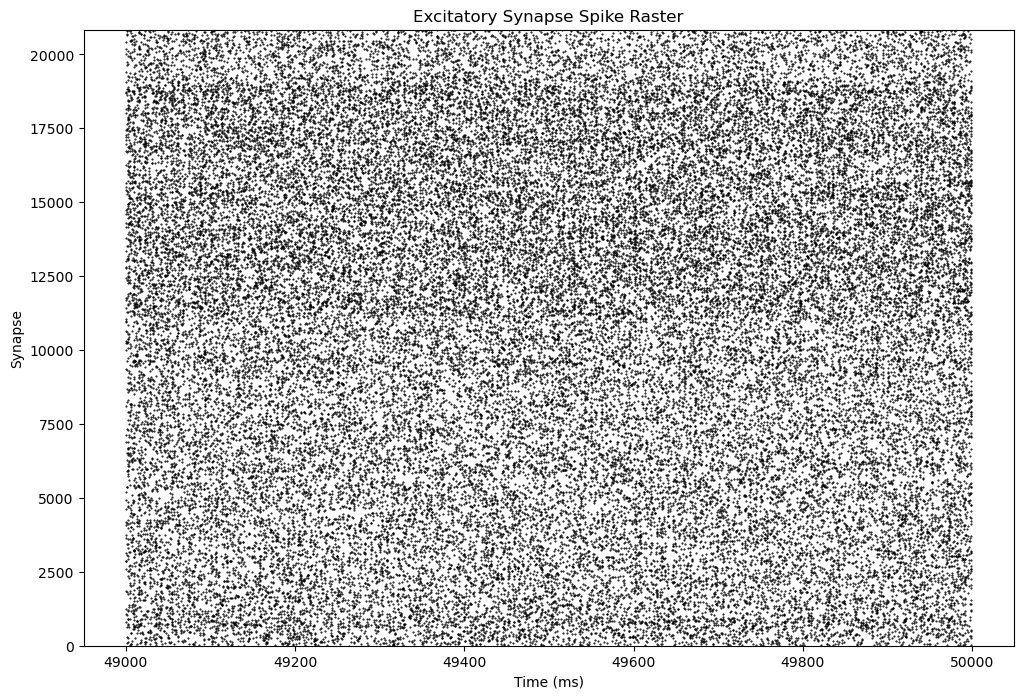

In [41]:
# Generate a spike raster plot for excitatory synapses
for synapse_analyzer in synapse_analyzers:
    synapse_analyzer.plot_spike_raster(
        synapse_types=['exc'],
        time_window=(49000, 50000),  # First second of simulation
        save_path=os.path.join(synapse_analyzer.sim_dir, 'exc_spike_raster.png'),
        title="Excitatory Synapse Spike Raster"
    )

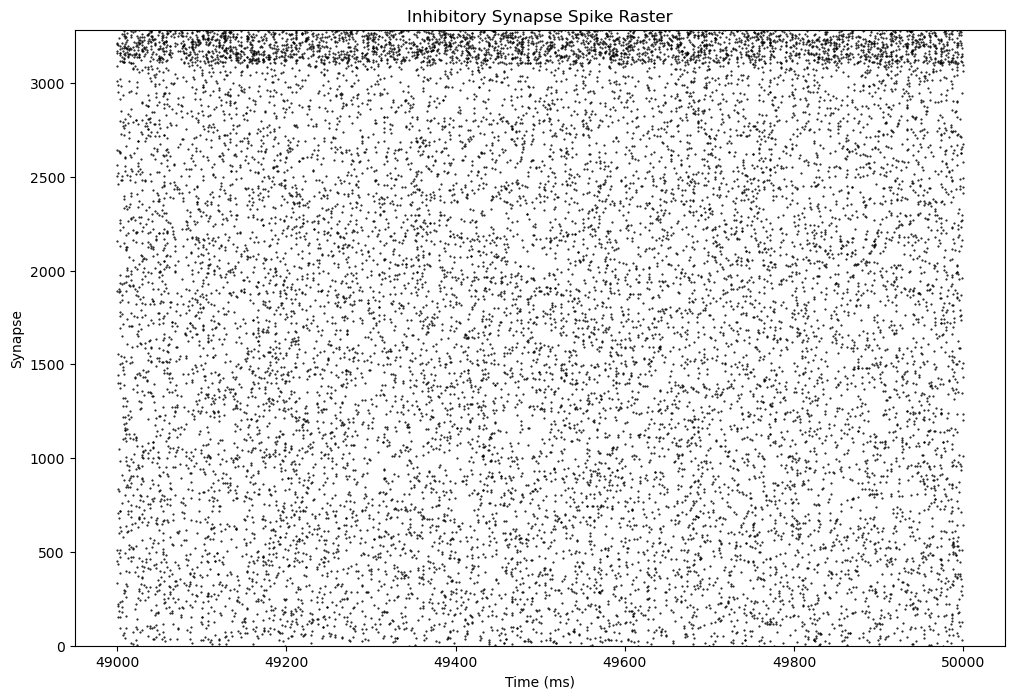

In [42]:
# Generate a spike raster plot for inhibitory synapses
for synapse_analyzer in synapse_analyzers:
    synapse_analyzer.plot_spike_raster(
        synapse_types=['inh'],
        time_window=(49000, 50000),  # First second of simulation
        save_path=os.path.join(synapse_analyzer.sim_dir, 'inh_spike_raster.png'),
        title="Inhibitory Synapse Spike Raster"
    )

In [43]:
# sim_dir = '/home/drfrbc/Neural-Modeling/simulations/2025-08-21-12-15-testing_rhythmic_inhibition/allinh_rhythmic_depth_0.30_Np500000'

In [44]:
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))

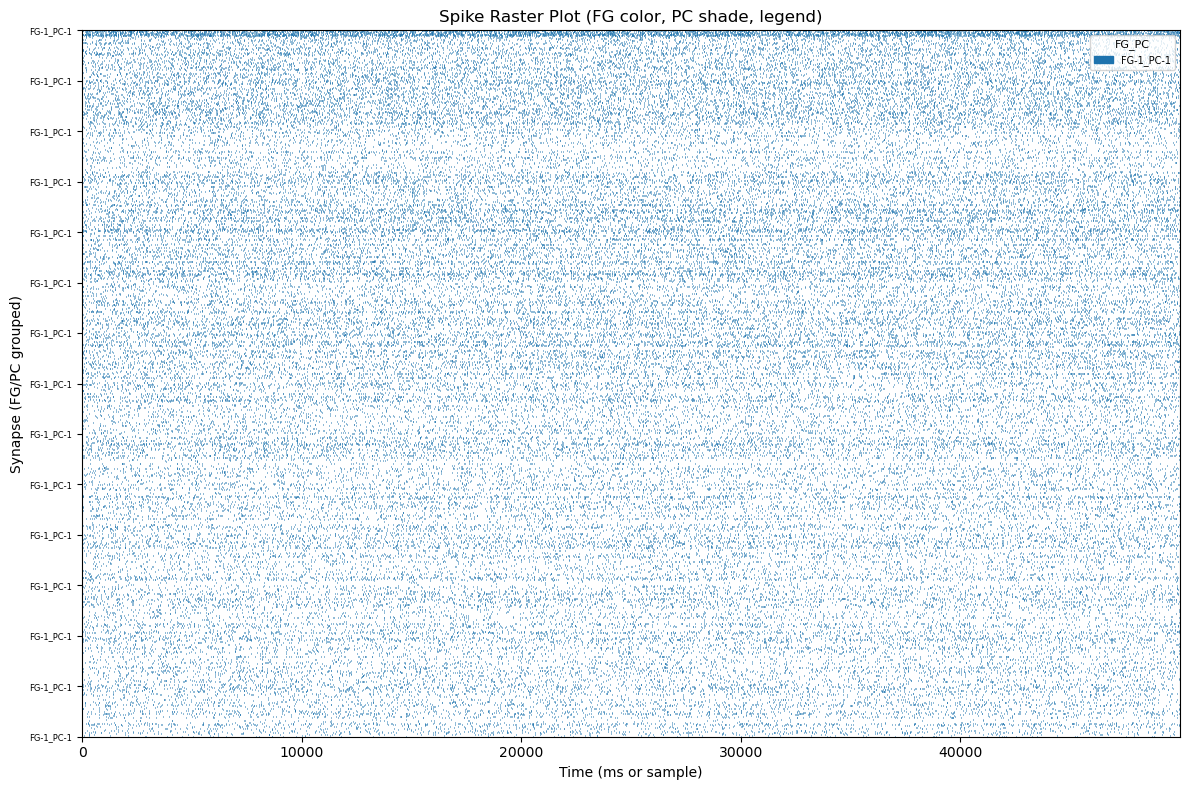

In [45]:
SynapseAnalyzer.plot_spike_raster_fgpc_legend(synapses)

## Copy over the sim_dir to notebooks/AA_sim.ipynb then notebooks/AA_post_sim.ipynb for simulation and analysis.

In [46]:
os.path.abspath(sim_dir) # for copying over

'/home/drfrbc/Neural-Modeling/simulations/2025-09-26-14-52-INH1.05x_NoEXCClustering_3xNA_0bg_synapses_with_rhythm0.00_tuftEXC1.4x_obliqueEXC0.6x_basalEXC0.90x/allinh_rhythmic_depth_0.00_Np5000'

Next, we need to simulate based on this folder. If you are in Colab then you will need to download the simulation folder or mount your drive and work through there 

### proceed to Neural-Modeling/notebooks/AA_sim.ipynb